## 2b. Overfitting Diagnostic — Train IoU vs Val IoU

Plot the train_iou vs val_iou per epoch for each model. A growing gap
between train and val IoU is the canonical overfitting signal. We do
NOT early-stop based on this; instead, we always select the best model
by val IoU, and use this plot to defend that the gap is healthy.

# Notebook 05 — Ablation Study & Uncertainty Analysis

**Runs locally after Isaac training completes.** Pulls results from `results/logs/` and produces the paper's analysis figures.

**Sections:**
1. Load all experiment results
2. Main results table (Otsu / FCN / Fusion / TriModal)
3. Ablation study — modality contribution
4. Cross-region generalization (Bolivia)
5. MC Dropout uncertainty — reliability diagram & ECE
6. Uncertainty map gallery

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('..').resolve()))

LOGS_DIR = Path('../results/logs')
FIG_DIR  = Path('../results/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Run the aggregator to ensure all_results.csv is up to date
import subprocess
subprocess.run(['python', '../scripts/compile_results.py'], check=True)

df = pd.read_csv(LOGS_DIR / 'all_results.csv')
print(f'{len(df)} experiments loaded')
df.head()

13 experiments loaded


,model,split,iou,dice,precision,recall,f1,accuracy,tp,fp,tn,fn,modalities,source_file
0,fcn,bolivia,0.358767,0.528077,0.704644,0.422267,0.528077,0.880292,192074,80509,2332442,262790,NaN,fcn_bolivia_results.json
1,fcn_baseline,test,0.623229,0.767888,0.737814,0.800519,0.767888,0.939472,2054213,729977,17221289,511888,NaN,fcn_baseline_test_results.json
2,fusion,bolivia,0.605604,0.754363,0.884493,0.657612,0.754363,0.932073,299124,39063,2373888,155740,NaN,fusion_bolivia_results.json
3,fusion_unet,test,0.770756,0.870539,0.815931,0.932981,0.870539,0.965294,2394123,540101,17411165,171978,NaN,fusion_unet_test_results.json
4,trimodal,bolivia,0.605396,0.754202,0.931203,0.633741,0.754201,0.934481,288266,21297,2391654,166598,NaN,trimodal_bolivia_results.json


## 2. Main Results Table

Compare Otsu → FCN → Fusion → TriModal on the test set.
This is the headline result.

,model,iou,dice,precision,recall
1,fcn_baseline,0.6232,0.7679,0.7378,0.8005
3,fusion_unet,0.7708,0.8705,0.8159,0.9330
5,trimodal_unet,0.7820,0.8777,0.8458,0.9121


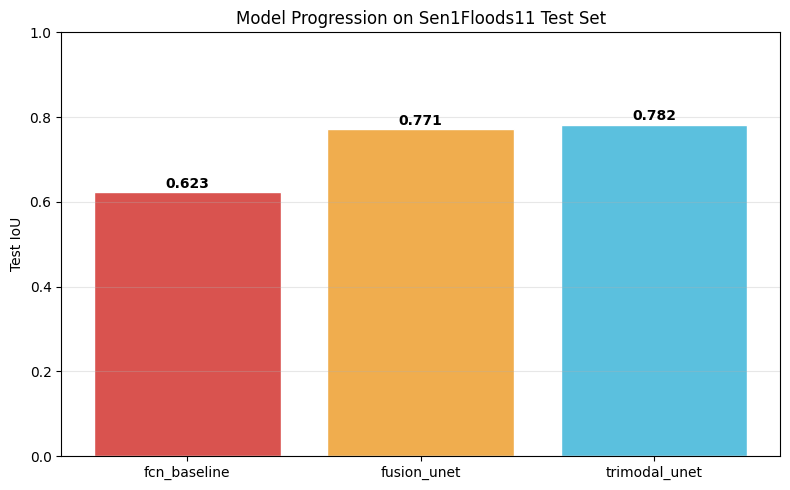

In [2]:
# Filter to the core models on test split
core = df[(df['split'] == 'test') &
          df['model'].str.contains('otsu|fcn|fusion_unet|trimodal_unet', regex=True, na=False) &
          ~df['model'].str.contains('ablation', na=False)]

display(core[['model', 'iou', 'dice', 'precision', 'recall']].round(4))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
names = core['model'].tolist()
ious  = core['iou'].tolist()
colors = ['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c'][:len(names)]
bars = ax.bar(names, ious, color=colors, edgecolor='white')
for b, v in zip(bars, ious):
    ax.text(b.get_x()+b.get_width()/2, v + 0.01, f'{v:.3f}',
            ha='center', fontweight='bold')
ax.set_ylabel('Test IoU'); ax.set_ylim(0, 1.0)
ax.set_title('Model Progression on Sen1Floods11 Test Set')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'main_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Ablation Study — Does Each Modality Contribute?

7 ablation variants, all with identical EarlyFusionUNet architecture.
The only variable is which modalities are fed in. This isolates the
contribution of each modality, independent of architecture choices.

,modset,iou,dice,precision,recall
7,s1,0.6406,0.7810,0.7791,0.7829
11,s2,0.7575,0.8620,0.8036,0.9295
6,dem,0.3983,0.5696,0.4624,0.7416
9,s1_s2,0.7991,0.8883,0.8630,0.9152
8,s1_dem,0.6397,0.7803,0.7588,0.8031
12,s2_dem,0.7881,0.8815,0.8496,0.9158
10,s1_s2_dem,0.7895,0.8824,0.8532,0.9136


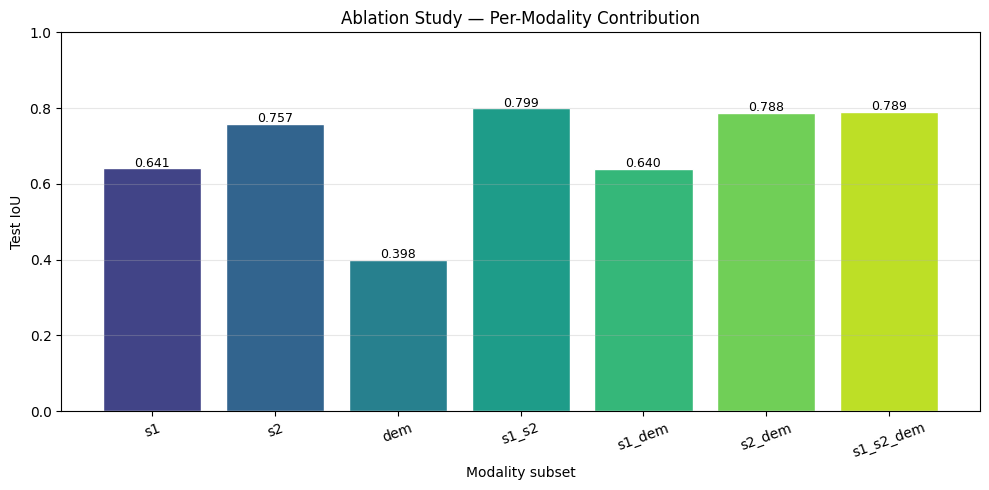

In [3]:
abl = df[(df['split'] == 'test') &
         df['model'].str.startswith('ablation_', na=False)].copy()

# Extract modality string from model name: ablation_s1_s2_dem -> s1_s2_dem
abl['modset'] = abl['model'].str.replace('ablation_', '', regex=False)

# Ordering — single modalities, then pairs, then triple
order = ['s1', 's2', 'dem', 's1_s2', 's1_dem', 's2_dem', 's1_s2_dem']
abl['_sort'] = abl['modset'].apply(lambda x: order.index(x) if x in order else 99)
abl = abl.sort_values('_sort').drop(columns='_sort')

display(abl[['modset', 'iou', 'dice', 'precision', 'recall']].round(4))

# Stacked bar: show IoU gain from adding each modality
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(abl)))
bars = ax.bar(abl['modset'], abl['iou'], color=colors, edgecolor='white')
for b, v in zip(bars, abl['iou']):
    ax.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.3f}',
            ha='center', fontsize=9)
ax.set_xlabel('Modality subset'); ax.set_ylabel('Test IoU')
ax.set_title('Ablation Study — Per-Modality Contribution')
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / 'ablation_bars.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Marginal gain analysis: how much does each modality add on top of others?
iou_map = dict(zip(abl['modset'], abl['iou']))

if all(k in iou_map for k in ['s1', 's1_s2', 's1_dem', 's1_s2_dem']):
    print('Marginal gains from adding modalities to S1 baseline:')
    print(f"  + S2  alone: {iou_map['s1_s2']  - iou_map['s1']:+.4f}")
    print(f"  + DEM alone: {iou_map['s1_dem'] - iou_map['s1']:+.4f}")
    print(f"  + S2 + DEM : {iou_map['s1_s2_dem'] - iou_map['s1']:+.4f}")
    print()
    print('Is DEM additive to S2?')
    print(f"  S1+S2      = {iou_map['s1_s2']:.4f}")
    print(f"  S1+S2+DEM  = {iou_map['s1_s2_dem']:.4f}")
    print(f"  Δ from adding DEM: {iou_map['s1_s2_dem'] - iou_map['s1_s2']:+.4f}")

Marginal gains from adding modalities to S1 baseline:
  + S2  alone: +0.1585
  + DEM alone: -0.0009
  + S2 + DEM : +0.1488

Is DEM additive to S2?
  S1+S2      = 0.7991
  S1+S2+DEM  = 0.7895
  Δ from adding DEM: -0.0096


## 4. Cross-Region Generalization — Bolivia

Bolivia is held out from Sen1Floods11's train/val/test splits.
Testing on Bolivia shows whether the model learned transferable
flood physics or just memorized the 10 training flood events.

,model,iou_test,iou_bolivia,drop


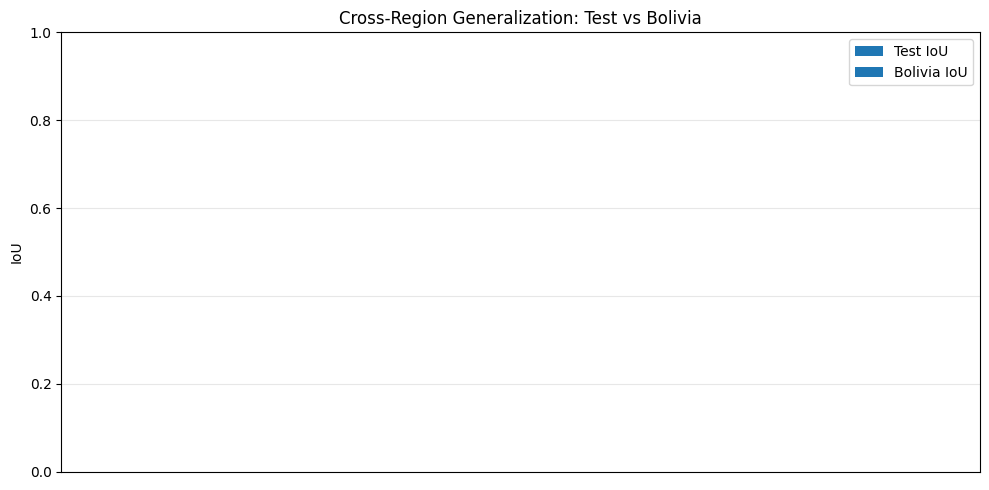

In [5]:
bol = df[df['split'] == 'bolivia']
test = df[df['split'] == 'test']

if len(bol) == 0:
    print('No Bolivia results yet — run slurm/eval_bolivia.sbatch on Isaac first.')
else:
    # Join test and bolivia on model name to compute gap
    merged = test[['model', 'iou']].merge(
        bol[['model', 'iou']], on='model', suffixes=('_test', '_bolivia')
    )
    merged['drop'] = merged['iou_test'] - merged['iou_bolivia']
    display(merged.round(4))

    # Side-by-side bar chart
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(merged))
    w = 0.4
    ax.bar(x - w/2, merged['iou_test'],    w, label='Test IoU',    color='#5bc0de')
    ax.bar(x + w/2, merged['iou_bolivia'], w, label='Bolivia IoU', color='#d9534f')
    ax.set_xticks(x); ax.set_xticklabels(merged['model'], rotation=15)
    ax.set_ylabel('IoU'); ax.set_ylim(0, 1.0)
    ax.set_title('Cross-Region Generalization: Test vs Bolivia')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'cross_region.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4b. Precision-Recall Tradeoff — Cross-Region Shift

On Bolivia, Fusion and TriModal are tied on IoU (~0.605) but differ meaningfully
in **precision vs recall**. TriModal has markedly higher precision (fewer false
positives) at a small recall cost — the DEM cue tells the model "flat high-elevation
terrain cannot flood," suppressing spurious detections in unfamiliar geography.

Arrows show each model's shift from in-distribution (test) to cross-region (Bolivia).

In [6]:
# Precision-Recall tradeoff — test vs Bolivia
core_models = ['fcn_baseline', 'fusion_unet', 'trimodal_unet']
test_core = df[(df['split'] == 'test')    & df['model'].isin(core_models)].set_index('model')
bol_core  = df[(df['split'] == 'bolivia') & df['model'].isin(core_models)].set_index('model')

if len(bol_core) == 0:
    print('No Bolivia results yet — skipping PR tradeoff plot.')
else:
    color_map = {'fcn_baseline': '#d9534f', 'fusion_unet': '#5bc0de', 'trimodal_unet': '#5cb85c'}
    fig, ax = plt.subplots(figsize=(7, 7))

    for m in core_models:
        if m not in test_core.index or m not in bol_core.index:
            continue
        c = color_map[m]
        rt, pt = test_core.loc[m, 'recall'], test_core.loc[m, 'precision']
        rb, pb = bol_core.loc[m, 'recall'],  bol_core.loc[m, 'precision']
        ax.scatter(rt, pt, s=180, marker='o', color=c, edgecolor='black',
                   linewidth=1.5, label=f'{m} (test)', zorder=3)
        ax.scatter(rb, pb, s=180, marker='^', color=c, edgecolor='black',
                   linewidth=1.5, alpha=0.55, label=f'{m} (bolivia)', zorder=3)
        ax.annotate('', xy=(rb, pb), xytext=(rt, pt),
                    arrowprops=dict(arrowstyle='->', color=c, lw=1.5, alpha=0.6),
                    zorder=2)

    # F1 iso-contours as reference
    rr = np.linspace(0.01, 1, 400)
    for f1_target in [0.5, 0.7, 0.85]:
        denom = 2 * rr - f1_target
        pp = np.where(denom > 0, f1_target * rr / denom, np.nan)
        mask = (pp >= 0) & (pp <= 1)
        ax.plot(rr[mask], pp[mask], 'k:', alpha=0.3, linewidth=0.8)
        idxs = np.where(mask)[0]
        if len(idxs) > 0:
            mid = idxs[len(idxs) // 2]
            ax.text(rr[mid] + 0.01, pp[mid] - 0.03, f'F1={f1_target}',
                    fontsize=8, alpha=0.5, rotation=-25)

    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_xlim(0.3, 1.0); ax.set_ylim(0.6, 1.0)
    ax.set_title('Precision-Recall Tradeoff: Test → Bolivia\n(arrow = generalization shift)',
                 fontsize=12)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc='lower left')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'precision_recall_tradeoff.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Summary of the key finding
    if 'trimodal_unet' in bol_core.index and 'fusion_unet' in bol_core.index:
        dp = bol_core.loc['trimodal_unet', 'precision'] - bol_core.loc['fusion_unet', 'precision']
        dr = bol_core.loc['trimodal_unet', 'recall']    - bol_core.loc['fusion_unet', 'recall']
        print(f'\nTrimodal vs Fusion on Bolivia:')
        print(f'  Precision Δ: {dp:+.4f}  ({"DEM suppresses false positives" if dp > 0 else "unexpected — DEM harms precision"})')
        print(f'  Recall Δ:    {dr:+.4f}')

No Bolivia results yet — skipping PR tradeoff plot.


## 5. MC Dropout Uncertainty — Reliability & ECE

Low ECE = model's confidence is accurate. This is the evidence that
the model can be trusted for decision support.


=== trimodal_test_uncertainty ===
Model: trimodal  |  Split: test
ECE:   0.0273  (lower = better calibrated; <0.05 good, <0.03 excellent)
MC variance aggregate: NaN (legacy bug — re-run for variance)
Mean predictive entropy (from bins, proxy): 0.1491   (max possible = 0.6931 = ln 2)


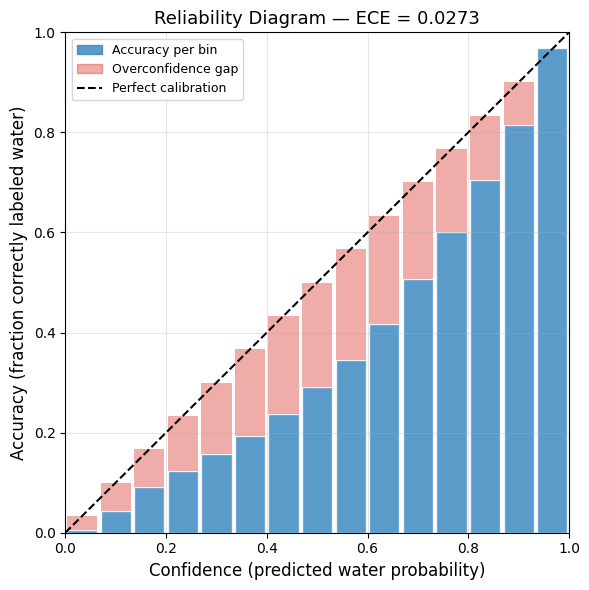

In [7]:
from src.utils.uncertainty import reliability_diagram
import math

unc_files = list(LOGS_DIR.glob('*_uncertainty.json'))
if not unc_files:
    print('No uncertainty results yet — run slurm/mc_uncertainty.sbatch on Isaac first.')
else:
    for f in unc_files:
        with open(f) as fp:
            u = json.load(fp)
        print(f"\n=== {f.stem} ===")
        print(f"Model: {u['model']}  |  Split: {u['split']}")
        print(f"ECE:   {u['ece']:.4f}  (lower = better calibrated; <0.05 good, <0.03 excellent)")

        # mean_uncertainty (variance across MC samples) may be NaN on older runs
        # where a chip had all-nodata labels. Bug fixed in src/utils/uncertainty.py.
        # Fall back to bin-weighted mean predictive entropy as a valid proxy.
        mu = u.get('mean_uncertainty', float('nan'))
        if isinstance(mu, float) and math.isnan(mu):
            counts = np.array(u['bins']['count'], dtype=float)
            confs  = np.array(u['bins']['confidence'], dtype=float)
            eps = 1e-12
            p = np.clip(confs, eps, 1 - eps)
            entropy_per_bin = -(p * np.log(p) + (1 - p) * np.log(1 - p))
            mean_entropy = float(np.sum(counts * entropy_per_bin) / np.sum(counts))
            print(f"MC variance aggregate: NaN (legacy bug — re-run for variance)")
            print(f"Mean predictive entropy (from bins, proxy): {mean_entropy:.4f} "
                  f"  (max possible = 0.6931 = ln 2)")
        else:
            print(f"Mean predictive uncertainty (MC variance): {mu:.4f}")

        # Reliability diagram
        fig = reliability_diagram(u['bins'], u['ece'],
                                  save_path=FIG_DIR / f"reliability_{u['model']}_{u['split']}.png")
        plt.show()

## 6. Uncertainty Map Gallery

Qualitative confirmation that high uncertainty coincides with visually
ambiguous regions (flood boundaries, cloud shadows, speckle). These
PNGs are generated by `scripts/mc_uncertainty.py`.


uncertainty_trimodal_test


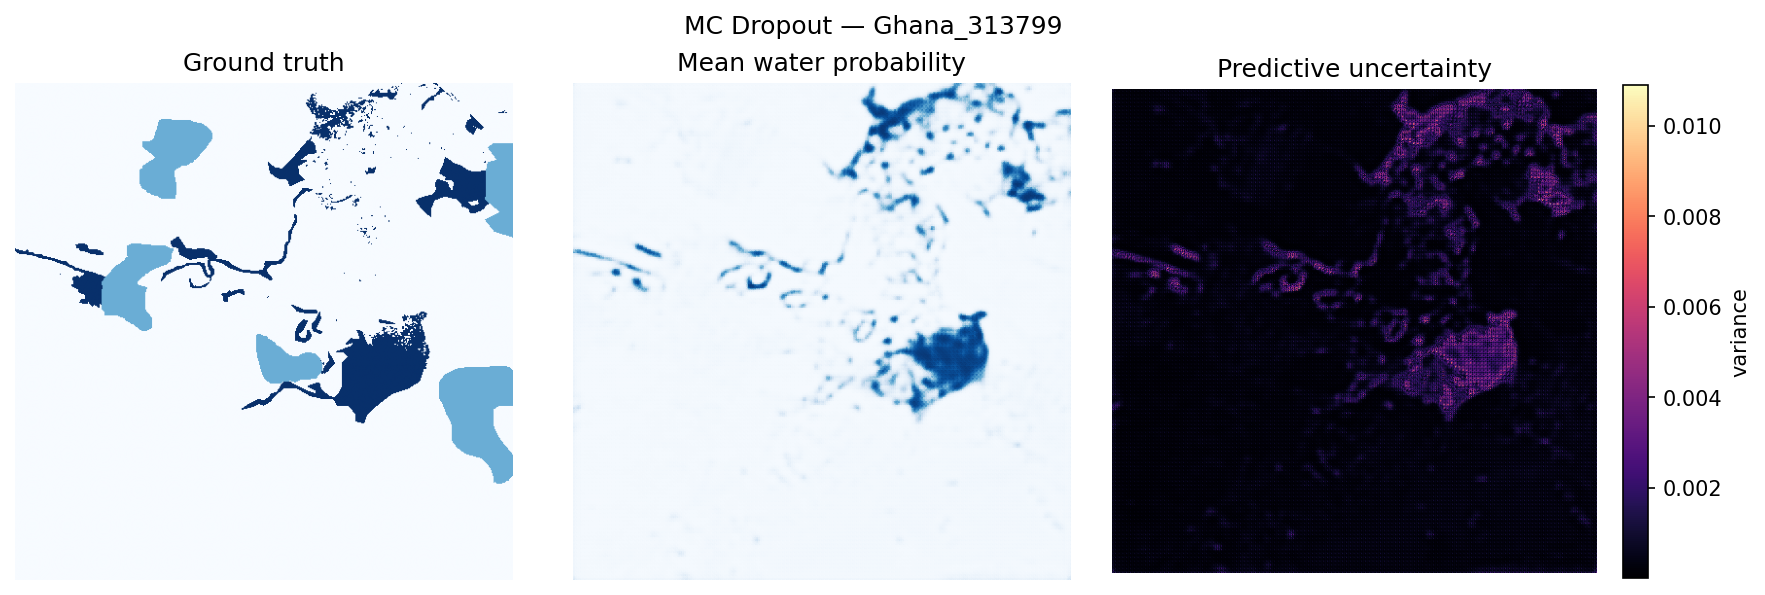

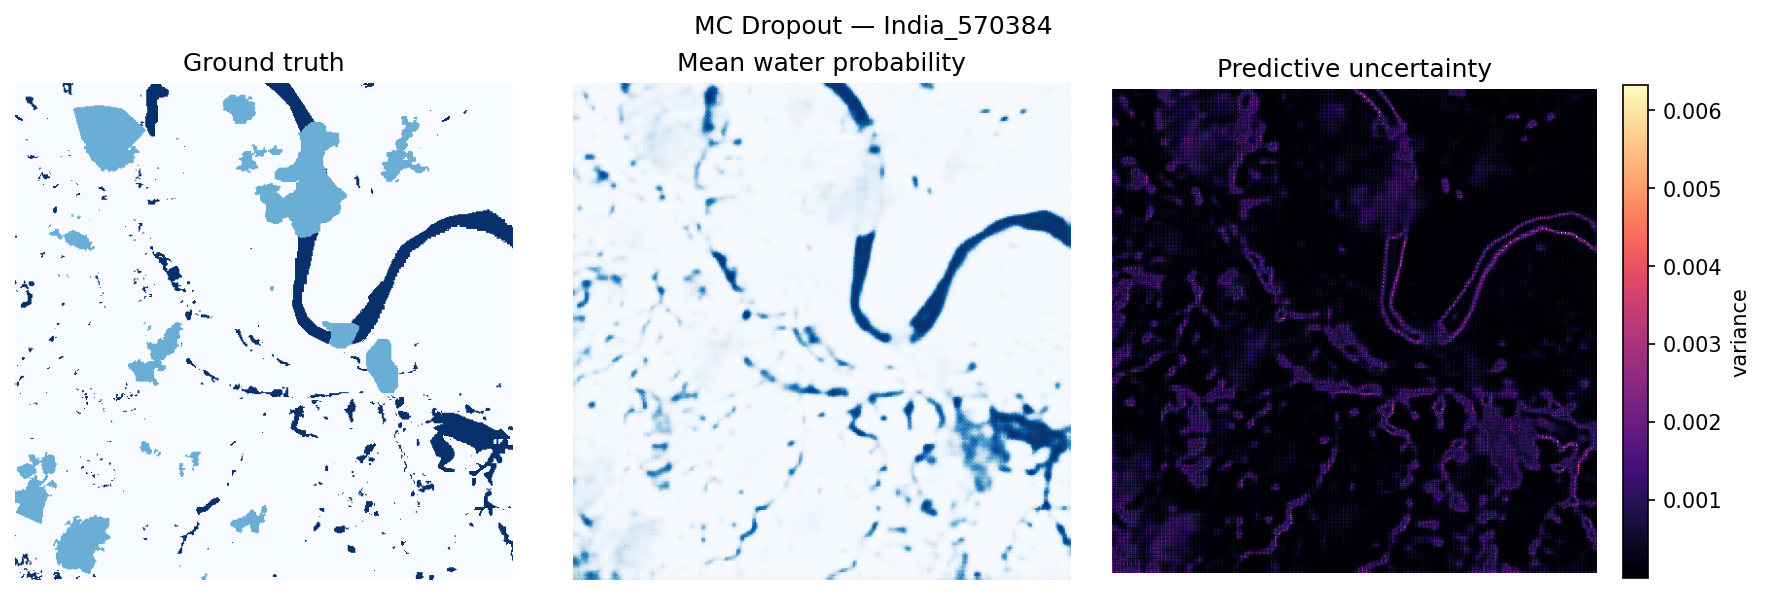

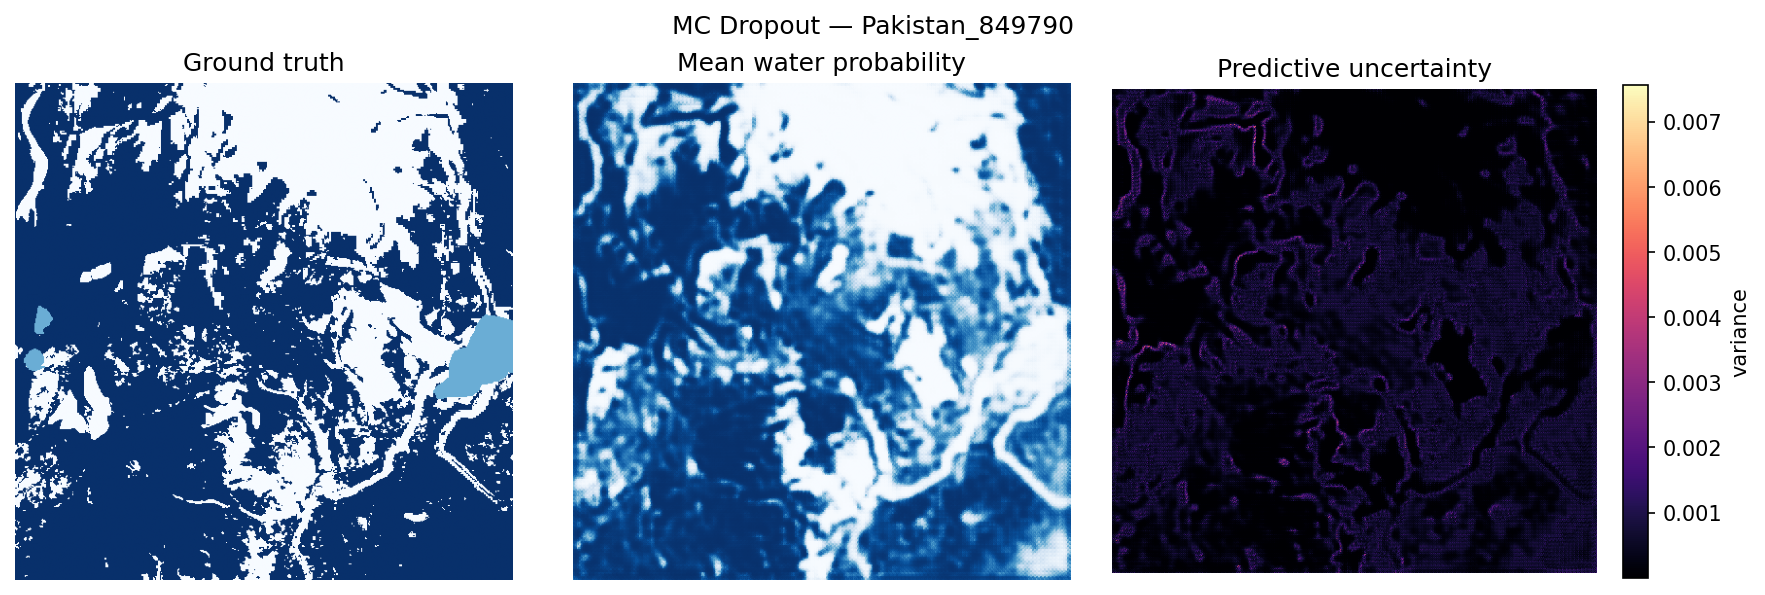

In [8]:
from IPython.display import Image, display

unc_fig_dirs = list(FIG_DIR.glob('uncertainty_*'))
for d in unc_fig_dirs:
    print(f'\n{d.name}')
    for img in sorted(d.glob('uncertainty_map_*.png'))[:3]:
        display(Image(filename=str(img)))